In [ ]:
import pandas as pd
import numpy as np
import dansy
import requests
import networkx as nx
from tqdm import tqdm
import matplotlib.pyplot as plt
from CoDIAC import InterPro
from collections import Counter

In [14]:
def fetch_TED_json(uniprotID, retries = 100):
    url = f'https://ted.cathdb.info/api/v1/uniprot/summary/{uniprotID}?skip=0&limit={retries}'
    response = requests.get(url)
    try:
        r=response.status_code
        if r==200: 
            data = response.json()
        elif r == 404:
            data = None
        elif r == 422:
            raise ValueError('There was a Validation Error on the TED side.')
        else:
            raise ValueError(f'Something really weird happened for {uniprotID} and got {r}')
    except requests.ConnectionError:
        # Probably need to retry the protein ID again so will return the uniprot ID back
        data = uniprotID
    except requests.HTTPError:
        data = None
    
    return data

def parse_TED_json(data, t = 70):
    '''Returns the TED domain data as a string in the form of TED_ID:CATH_Label:start:end;DomainB...
    
    Domains are restricted to those with an pLDDT >= 70 as there is a good confidence in the prediction from AlphaFold in its structure. However, this can be adjusted if desired.'''

    # Check that there are domains otherwise return a string
    if data['count'] == 0:
        res = ''
    else:
        res = []
        for d in data['data']:
            if d['plddt'] >= t:
                domain_data = [d['ted_id'],d['cath_label']]
                if d['chopping'].count('_') == 0: # Most domains will fall under this
                    se = d['chopping'].split('-')
                    domain_data.extend(se)
                    res.append(':'.join(domain_data))
                else: # For some TED domains this refers to discontinuous domains. For this analysis, I will largely treat these as continuous instead since I am looking for overlaps between existing annotations in Interpro.
                    bounds = d['chopping'].split('_')  
                    se = [bounds[0].split('-')[0],bounds[-1].split('-')[1]]
                    domain_data.extend(se)
                    res.append(':'.join(domain_data))
        
        res = ';'.join(res)

    return res

In [2]:
ref = dansy.import_proteome_files(ref_file_dir='data/Current_Human_Proteome',
                                  ref_file_suffix='2026_0715.csv')
proteome_dansy = dansy.dansy(ref= ref, n=10, verbose=False)

In [3]:
# Now get the isolates and then fetch all the proteins of interest from those
isolates = nx.isolates(proteome_dansy.G)
protsOI = []
for i in isolates:
    x = proteome_dansy.retrieve_ngram_protein_info(i)
    protsOI.extend(x['UniProt ID'].tolist())
    

In [4]:
# Let's also grab the proteins without any annotated domains for the time being as a nice little additional information check for now. Maybe will include in the response to the reviewer
no_dom_prots = ref[ref['Interpro Domain Architecture IDs'] == '']['UniProt ID'].tolist()


protsOI = sorted(set(protsOI).union(no_dom_prots)) # There are two proteins which span multiple isolates for some reason
len(protsOI)

8066

In [15]:
# Alright now let's download the data from the TED database for cross-checking

ted_results = {}
failed_ids = []
for prot in tqdm(protsOI):
    x = fetch_TED_json(prot)
    if x is not None and x != prot:
        r = parse_TED_json(x)
        ted_results[prot] = r
    elif x == prot:
        failed_ids.append(prot)

100%|██████████| 8066/8066 [41:34<00:00,  3.23it/s]  


In [16]:
# retry any failed IDs until none remain
failsafe = 0
while failed_ids and failsafe < 20:
    for prot in failed_ids[:]:
        x = fetch_TED_json(prot, retries=500)
        if x is not None and x != prot:
            r = parse_TED_json(x)
            ted_results[prot] = r
            failed_ids.remove(prot)
    failsafe += 1
    print(len(failed_ids))

In [17]:
# Now let's write the results to a csv file so that I don't have to fetch from the TED database again
df = pd.DataFrame.from_dict(ted_results, orient='index')
df.to_csv('TED_domains_isolates_unannotated.csv')

In [3]:
# Importing the file if restarting
df = pd.read_csv('TED_domains_isolates_unannotated.csv', index_col=0,).fillna('')

In [4]:
df.shape

(8002, 1)

In [ ]:
# For imported data it treats the column as 0 because I did not assign a column name in the initial file creation.
df = df[df['0'] != '']

In [7]:
df.shape

(6182, 1)

In [8]:
def check_overlap(original_bounds, new_bounds, threshold = 0.5):

    # Get amino acid position ranges
    original_range = set(range(*original_bounds))
    new_range = set(range(*new_bounds))

    # Check the range intersection
    intersect = len(new_range.intersection(original_range))/len(min(original_range, new_range)) > threshold

    return intersect

def get_domain_boundaries(domainInfo):
    x = domainInfo.split(':')[2:4]
    return [int(i) for i in x]

def resolve_architecture(new_doms, orig_doms):
    
    if orig_doms != '':
        orig_doms2 = orig_doms.split(';')
        all_doms = [*new_doms, *orig_doms2]
    else:
        all_doms = new_doms.copy()
    dom_start_dict = {x:int(x.split(':')[2]) for x in all_doms}
    sorted_dict = sorted(dom_start_dict, key = dom_start_dict.get,reverse=False)

    return '|'.join(sorted_dict)
    

In [9]:
# Now let's start comparing the domain boundaries
prots_w_newdoms = {}
chck = set()
ted_dom_count = 0
for prot in tqdm(df.index):
    # Get the original data
    orig_info = proteome_dansy.retrieve_protein_info(prot)['Interpro Domains'].values[0]
    orig_domains = orig_info.split(';')
    ted_info = df.loc[prot][0]
    kept_doms = []
    if orig_domains != ['']:
        for dom in ted_info.split(';'):
            new_bounds = get_domain_boundaries(dom)
            ov_check = [check_overlap(get_domain_boundaries(i), new_bounds) for i in orig_domains]
            if not any(ov_check):
                if dom.split(':')[1] == '-':
                    fix_dom = dom.split(':')
                    fix_dom[1] = f'Novel_TED_{ted_dom_count:05}'
                    ted_dom_count += 1
                    dom = ':'.join(fix_dom)
                kept_doms.append(dom)
                
    else:
        kept_doms = []
        for dom in ted_info.split(';'):
            if dom.split(':')[1] == '-':
                fix_dom = dom.split(':')
                fix_dom[1] = f'Novel_TED_{ted_dom_count:05}'
                ted_dom_count += 1
                dom = ':'.join(fix_dom)
            kept_doms.append(dom)
    if kept_doms:
        prots_w_newdoms[prot] = kept_doms

  0%|          | 0/6182 [00:00<?, ?it/s]/var/folders/3q/_kyvxhrx2zv25qm8x2nv6c0h0000gr/T/ipykernel_65990/2571110347.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ted_info = df.loc[prot][0]
100%|██████████| 6182/6182 [00:01<00:00, 3210.62it/s]


In [10]:
dom

'AF-U3KPV4-F1-model_v4_TED01:1.20.5:2:32'

In [11]:
x = prots_w_newdoms['Q9Y6H5'].copy()
y = proteome_dansy.retrieve_protein_info('Q9Y6H5')['Interpro Domains'].values[0]
resolve_architecture(x,y)

'AF-Q9Y6H5-F1-model_v4_TED01:1.25.40.20:312:413|AF-Q9Y6H5-F1-model_v4_TED02:1.25.40.20:416:521|SNCAIP_SNCA-bd:IPR032027:512:555'

In [12]:
x = prots_w_newdoms['Q9Y6J0'].copy()
y = proteome_dansy.retrieve_protein_info('Q9Y6J0')['Interpro Domains'].values[0]
resolve_architecture(x,y)

'AF-Q9Y6J0-F1-model_v4_TED01:1.25.40.10:30:250|AF-Q9Y6J0-F1-model_v4_TED02:Novel_TED_02321:259:523|AF-Q9Y6J0-F1-model_v4_TED03:Novel_TED_02322:531:687|AF-Q9Y6J0-F1-model_v4_TED04:Novel_TED_02323:750:868|AF-Q9Y6J0-F1-model_v4_TED05:Novel_TED_02324:886:973|AF-Q9Y6J0-F1-model_v4_TED06:Novel_TED_02325:974:1087|AF-Q9Y6J0-F1-model_v4_TED07:Novel_TED_02326:1228:1524|AF-Q9Y6J0-F1-model_v4_TED08:Novel_TED_02327:1854:1917|MEF2-bd:IPR015134:2156:2190'

In [13]:
# Create a new version of the reference file as a subset with the existing proteins that have unannotated domains that were identified by TED
new_ref = ref.copy()
new_ref.set_index('UniProt ID', inplace=True)
new_ref = new_ref.filter([k for k in prots_w_newdoms.keys()], axis = 0)

In [14]:
new_ref['Interpro Domains'] = [
    resolve_architecture(
        prots_w_newdoms[uniprot_id],
        proteome_dansy.retrieve_protein_info(uniprot_id)['Interpro Domains'].values[0]
    )
    for uniprot_id in new_ref.index
]

new_ref['Interpro Domain Architecture IDs'] = new_ref['Interpro Domains'].apply(lambda x: '|'.join([i.split(':')[1] for i in x.split('|')]))
new_ref['Interpro Domain Architecture'] = new_ref['Interpro Domains'].apply(lambda x: '|'.join([i.split(':')[0] for i in x.split('|')]))
new_ref.reset_index(inplace=True, names='UniProt ID')

In [15]:
new_ref


,UniProt ID,Gene,Species,Uniprot Domains,Ref Sequence,PDB IDs,Uniprot Domain Architecture,Interpro Domains,Interpro Domain Architecture,Interpro Domain Architecture IDs
0,A0A075B6L2,TRGV11,Homo sapiens,Ig-like:23:>119,MPLVVAVIFFSLWVFALGQLEQPEISISRPANKSAHISWKASIQGF...,,Ig-like,AF-A0A075B6L2-F1-model_v4_TED01:2.60.40.10:33:116,AF-A0A075B6L2-F1-model_v4_TED01,2.60.40.10
1,A0A075B734,AQP7B,Homo sapiens,,MVQASGHRRSTRGSKMVSWSVIAKIQEIWCEEDERKMVREFLAEFM...,,,AF-A0A075B734-F1-model_v4_TED01:1.20.1080.10:2...,AF-A0A075B734-F1-model_v4_TED01,1.20.1080.10
2,A0A087WTH1,TMEM265,Homo sapiens,,MEDEEKAVEILGNTEAAHPPSPIRCCWLRLRCLAATSIICGCSCLG...,,,AF-A0A087WTH1-F1-model_v4_TED01:1.10.287:22:108,AF-A0A087WTH1-F1-model_v4_TED01,1.10.287
3,A0A087WWS6,IFNA13,Homo sapiens,,MMASPFALLMALVVLSCKSSCSLGCDLPETHSLDNRRTLMLLAQMS...,,,AF-A0A087WWS6-F1-model_v4_TED01:1.20.1250.10:3...,AF-A0A087WWS6-F1-model_v4_TED01,1.20.1250.10
4,A0A087X1C5,CYP2D7,Homo sapiens,,MGLEALVPLAMIVAIFLLLVDLMHRHQRWAARYPPGPLPLPGLGNL...,,,AF-A0A087X1C5-F1-model_v4_TED01:1.10.630.10:32...,AF-A0A087X1C5-F1-model_v4_TED01,1.10.630.10
...,...,...,...,...,...,...,...,...,...,...
4859,Q9Y6X0,SETBP1,Homo sapiens,,MESRETLSSSRQRGGESDFLPVSSAKPPAAPGCAGEPLLSTPGPGK...,,,AF-Q9Y6X0-F1-model_v4_TED01:Novel_TED_02331:14...,AF-Q9Y6X0-F1-model_v4_TED01,Novel_TED_02331
4860,Q9Y6X1,SERP1,Homo sapiens,,MVAKQRIRMANEKHSKNITQRGNVAKTSRNAPEEKASVGPWLLALF...,,,AF-Q9Y6X1-F1-model_v4_TED01:1.20.5:38:66,AF-Q9Y6X1-F1-model_v4_TED01,1.20.5
4861,Q9Y6X4,FAM169A,Homo sapiens,,MAFPVDMLENCSHEELENSAEDYMSDLRCGDPENPECFSLLNITIP...,,,AF-Q9Y6X4-F1-model_v4_TED01:Novel_TED_02332:16...,AF-Q9Y6X4-F1-model_v4_TED01,Novel_TED_02332
4862,Q9Y6X5,ENPP4,Homo sapiens,,MKLLVILLFSGLITGFRSDSSSSLPPKLLLVSFDGFRADYLKNYEF...,4LQY;4LR2,,AF-Q9Y6X5-F1-model_v4_TED01:3.40.720.10:28:396...,AF-Q9Y6X5-F1-model_v4_TED01|AF-Q9Y6X5-F1-model...,3.40.720.10|3.30.1360.180


In [20]:
# For the networks to be drawn later
network_params = {'node_size':1, 'edgecolors':'k',
        'edge_color':'#808080', 'width':0.05, 'linewidths':0.1}

In [21]:
isols_ted = dansy.dansy(ref = new_ref.reset_index(), n = 10, **network_params)

Starting to fetch n-grams.
Finished getting all n-grams
Collapsing n-grams
Finished creating edgelist


In [39]:
cath_ngrams = [x for x in isols_ted.all_ngrams if '.' in x]
cath_doms = set()
cath_levels = []
weird = []
for ngram in cath_ngrams:
    for dom in ngram.split('|'):
        if '.' in dom:
            x = dom.split(',') #Some instances of two CATH designations
            for d in x:
                cath_doms.add(d)
                l = len(d.split('.'))
                cath_levels.append(l)
              




In [40]:
Counter(cath_levels)

Counter({4: 3139, 3: 2865})

In [43]:
2865/6004

0.4771818787475017

In [33]:
2199/5671

0.38776229941809204

In [22]:
isols_ted.summary(detailed=True)

,
name,Domain n-gram Network
Proteins,4864
n-grams,3126
Network Isolates,1368
Network Connected Components,1432
Collapsed n-grams,3150
Network Edges,2920
Maximum Length of Protein Domain Architecture,16


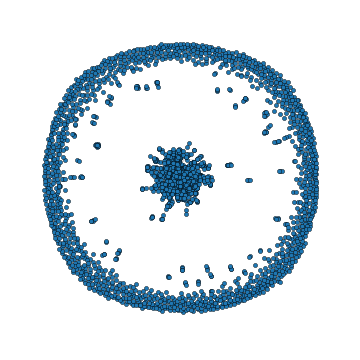

In [36]:

isols_ted.draw_network()
plt.gcf().set_dpi(300)
plt.gcf().set_figheight(1)
plt.gcf().set_figwidth(1)

In [37]:
max(isols_ted.G.degree(),key=lambda x:x[1])

('1.20.5', 362)

In [39]:
sorted(isols_ted.G.degree(), key=lambda x:x[1],reverse=True)

[('1.20.5', 362),
 ('3.40.50', 175),
 ('1.25.40', 171),
 ('1.10.287', 133),
 ('2.60.40', 84),
 ('1.20.58', 76),
 ('1.25.40.10', 57),
 ('2.130.10', 55),
 ('2.130.10.10', 54),
 ('1.25.10', 48),
 ('1.10.10', 45),
 ('2.60.40.10', 43),
 ('3.80.10.10', 34),
 ('1.20.120', 34),
 ('1.25.10.10', 34),
 ('1.20.1250', 30),
 ('3.90.550', 30),
 ('2.60.120', 29),
 ('3.30.70', 29),
 ('1.25.40.20', 28),
 ('1.20.5|1.20.5', 27),
 ('3.30.420', 27),
 ('3.40.50.300', 24),
 ('2.40.128', 23),
 ('1.20.1250.20', 22),
 ('3.90.550.10', 22),
 ('3.30.420.40', 20),
 ('1.20.1050', 19),
 ('3.40.50.150', 18),
 ('3.10.20', 17),
 ('1.20.930', 17),
 ('3.40.50.1000', 16),
 ('IPR020846|1.20.1250.20', 15),
 ('IPR020846', 15),
 ('1.10.8', 15),
 ('1.25.40.10|1.25.40', 14),
 ('1.25.40|1.25.40', 14),
 ('2.40.50', 14),
 ('IPR056899|2.60.40.10|IPR003343|IPR058779', 13),
 ('1.25.10.10|1.25.10', 13),
 ('1.10.150', 13),
 ('2.60.40,2.60.40', 13),
 ('1.20.1270', 13),
 ('2.30.30', 13),
 ('3.40.50,3.40.50', 12),
 ('1.25.40,1.25.40', 11),


In [40]:
isols_ted.summary()

,
name,Domain n-gram Network
Proteins,4864
n-grams,3126
Network Isolates,1368
Network Connected Components,1432
